# **Rule-Based Text Analysis**

## Project: Identifying and Analyzing Information Gaps in Women's Health Information

**Key:**

- 'Analyzing' dataset: Dataset of articles with female-specific topics
- 'Identifying' dataset: Dataset of articles with non-sex-specific diseases, which may also present differently between male and female patients

### Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import json
import re
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Download required NLTK data
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')

# Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Data Preprocessing

In [ ]:
import json
import pandas as pd

def load_and_flatten_json(filepath):
    """Reads JSON and flattens the nested 'results' arrays into a standard DataFrame."""
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)

    articles = []
    for row in data:
        if 'results' in row and isinstance(row['results'], list):
            for result in row['results']:
                result['query'] = row.get('query', '')
                articles.append(result)

    return pd.DataFrame(articles)

"""
Read JSON datasets
"""
"""
Modifying filepaths for Google Colab run

analyzing_df = load_and_flatten_json('data/analyzing.json')
identifying_df = load_and_flatten_json('data/identifying.json')
"""
analyzing_df = load_and_flatten_json('/content/drive/MyDrive/honors-thesis/data/analyzing.json')
identifying_df = load_and_flatten_json('/content/drive/MyDrive/honors-thesis/data/identifying.json')

# Read Phrase Arrays
"""
phrases_df = pd.read_excel('phrase_arrays.xlsx')
Modified filepaths for Google Colab run
"""
phrases_df = pd.read_excel('/content/drive/MyDrive/honors-thesis/phrase_arrays.xlsx')

"""
Extract Phrase Lists from Spreadsheet
"""
phrase_dict = {
    'mechanism_phrases': phrases_df['mechanism_phrases'].dropna().tolist(),
    'provider_phrases': phrases_df['provider_phrases'].dropna().tolist(),
    'endorsement_phrases': phrases_df['endorsement_phrases'].dropna().tolist(),
    'uncertainty_phrases': phrases_df['uncertainty_phrases'].dropna().tolist(),
    'female_associated': phrases_df['female_associated'].dropna().tolist() if 'female_associated' in phrases_df.columns else []
}

"""
Data Cleaning Pipeline
"""
def clean_dataset(df, dataset_type="identifying"):
    # Drop exact duplicates based on article content
    df = df.drop_duplicates(subset=['full_article_text'])

    # Drop "access denied" errors from scraping
    df = df[~df['full_article_text'].str.contains("access denied", case=False, na=False)]

    # Dataset-specific rules
    if dataset_type == "analyzing":
        # Drop articles containing "male" as a standalone word in the title
        df = df[~df['title'].str.contains(r'\bmale\b', case=False, na=False)]

    return df

analyzing_df = clean_dataset(analyzing_df, dataset_type="analyzing")
identifying_df = clean_dataset(identifying_df, dataset_type="identifying")

"""
Downsampling 'Analyzing' Dataset
"""
# Downsample the 'analyzing' dataset by dropping 4 articles from each query group
analyzing_df = analyzing_df.groupby('query', group_keys=False).apply(
    lambda x: x.sample(n=max(0, len(x) - 4), random_state=42)
)

/tmp/ipykernel_19265/1982992094.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analyzing_df = analyzing_df.groupby('query', group_keys=False).apply(


In [ ]:
analyzing_df.columns, identifying_df.columns

(Index(['title', 'url', 'snippet', 'full_article_text', 'query'], dtype='object'),
 Index(['title', 'url', 'snippet', 'full_article_text', 'query'], dtype='object'))

In [ ]:
analyzing_df.shape, identifying_df.shape

((415, 5), (395, 5))

### Feature Extraction

In [ ]:
def calculate_raw_tally(text, phrase_list):
    """
    Calculates the raw tally of phrases.
    Uses flexible whitespace matching to prevent zero-scores from scraping artifacts.
    """
    if not isinstance(text, str) or not text.strip() or not phrase_list:
        return 0

    # Strip punctuation and normalize whitespace for resilient matching
    text_clean = re.sub(r'[^\w\s]', ' ', text.lower())
    text_clean = re.sub(r'\s+', ' ', text_clean).strip()

    count = 0
    for phrase in phrase_list:
        if not isinstance(phrase, str):
            continue

        phrase_clean = re.sub(r'[^\w\s]', ' ', phrase.lower())
        phrase_clean = re.sub(r'\s+', ' ', phrase_clean).strip()

        if not phrase_clean:
            continue

        # Match the phrase allowing for variable spacing
        pattern = r'\b' + re.escape(phrase_clean) + r'\b'
        count += len(re.findall(pattern, text_clean))

    return count

def calculate_normalized_sentiment(text):
    """
    Calculates sentiment by dividing total word sentiment by total word count.
    """
    if not isinstance(text, str) or not text.strip():
        return 0.0

    words = nltk.word_tokenize(text.lower())
    if not words:
        return 0.0

    # Sum the compound score of each individual word
    total_sentiment = sum(sia.polarity_scores(word)['compound'] for word in words)
    return total_sentiment / len(words)

def apply_nlp_metrics(df, dataset_type="analyzing"):
    # Calculate word count
    df['word_count'] = df['full_article_text'].apply(
        lambda x: len(nltk.word_tokenize(str(x))) if isinstance(x, str) else 0
    )

    # Apply sentiment scores
    df['sentiment_score'] = df['full_article_text'].apply(calculate_normalized_sentiment)

    # Apply and normalize raw phrase tallies (occurrences per 1,000 words)
    categories = ['mechanism_phrases', 'provider_phrases', 'endorsement_phrases', 'uncertainty_phrases', 'female_associated']
    for cat in categories:
        raw_tally = df['full_article_text'].apply(
            lambda x: calculate_raw_tally(str(x), phrase_dict.get(cat, []))
        )
        # Prevent division by zero and calculate normalized score
        df[f'{cat}_score'] = (raw_tally / df['word_count'].replace(0, 1)) * 1000

    return df

analyzing_df = apply_nlp_metrics(analyzing_df, "analyzing")
identifying_df = apply_nlp_metrics(identifying_df, "identifying")

### Structural Analysis

In [ ]:
def analyze_headings(full_article_text):
    """
    Evaluates comprehensiveness based on heading counts and target sections.
    Extracts headings from <h2...h6> tags within the full article text.
    """
    if not isinstance(full_article_text, str):
        return 0

    # Extract text within h2-h6 tags
    headings_list = re.findall(r'<h[2-6][^>]*>(.*?)</h[2-6]>', full_article_text, flags=re.IGNORECASE)

    score = len(headings_list) # Base score on structural breakdown

    # Bonus points for standard comprehensive clinical sections
    comprehensive_markers = ['symptom', 'cause', 'treatment', 'diagnosis', 'prevention', 'risk']
    headings_text = " ".join(headings_list).lower()

    for marker in comprehensive_markers:
        if marker in headings_text:
            score += 2 # Weighted addition for covering key medical subsections

    return score

# Apply directly to the 'full_article_text' column
if 'full_article_text' in analyzing_df.columns:
    analyzing_df['comprehensiveness_score'] = analyzing_df['full_article_text'].apply(analyze_headings)
if 'full_article_text' in identifying_df.columns:
    identifying_df['comprehensiveness_score'] = identifying_df['full_article_text'].apply(analyze_headings)

### Visualizations

In [ ]:
sns.set_theme(style="whitegrid")

analyzing_df['Dataset'] = 'Female-Specific'
identifying_df['Dataset'] = 'Neutral, but Differently-Presenting'

common_cols = [
    'word_count', 'sentiment_score', 'mechanism_phrases_score',
    'provider_phrases_score', 'endorsement_phrases_score',
    'uncertainty_phrases_score', 'Dataset'
]
combined_df = pd.concat([analyzing_df[common_cols], identifying_df[common_cols]])

metrics_to_plot = [
    'sentiment_score', 'mechanism_phrases_score', 'provider_phrases_score',
    'endorsement_phrases_score', 'uncertainty_phrases_score', 'female_associated_score'
]

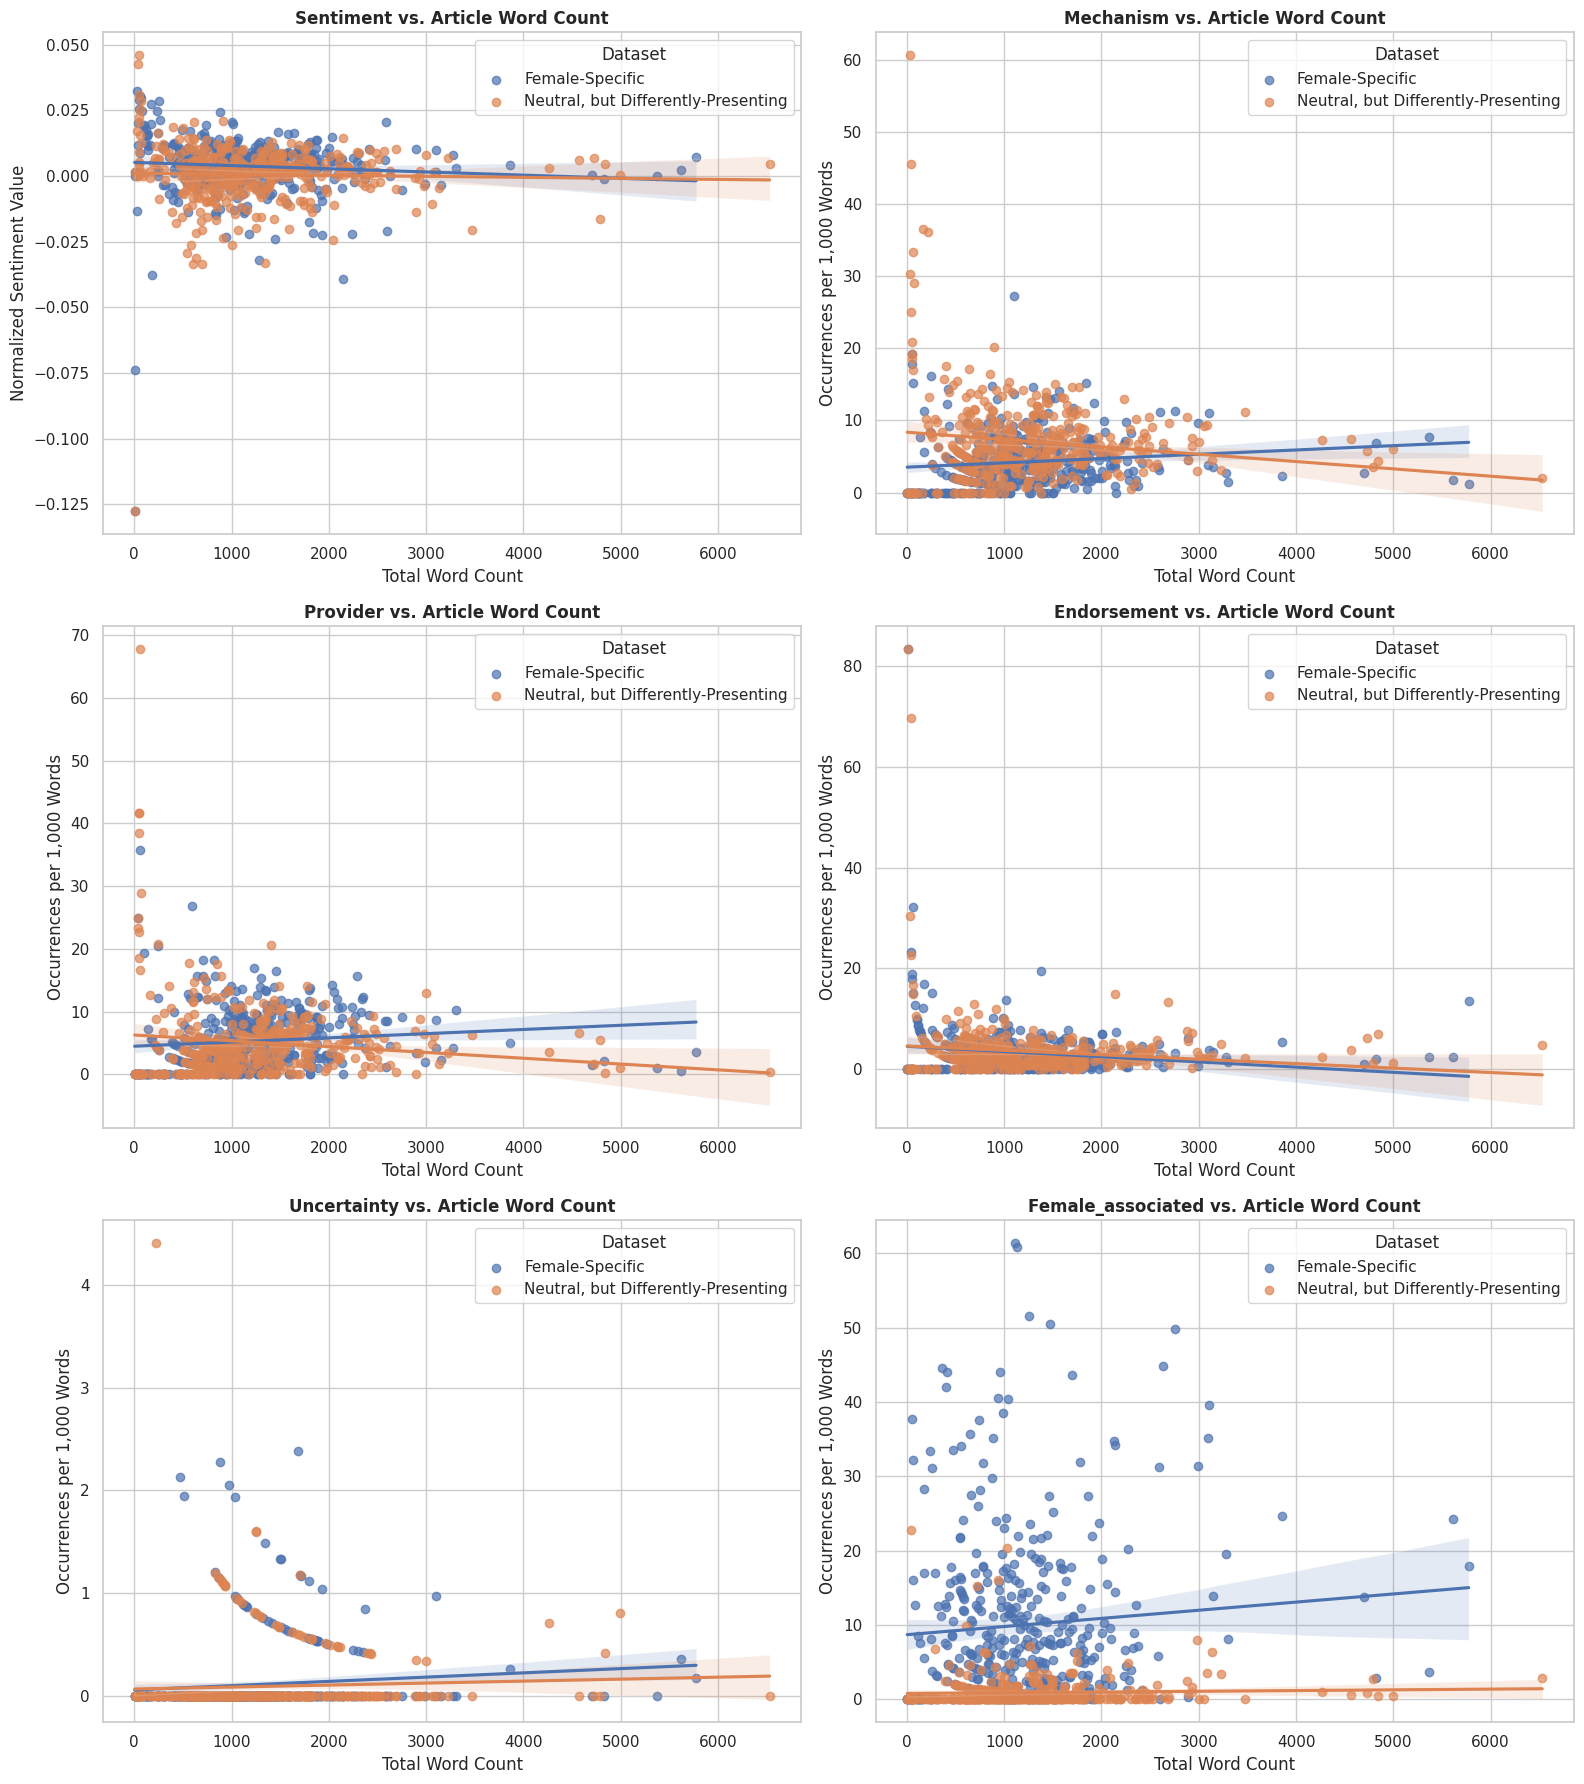

In [ ]:
# --- 1. Comparative Scatterplots ---
# Recreate common_cols and combined_df to include 'female_associated_score'
common_cols = [
    'word_count', 'sentiment_score', 'mechanism_phrases_score',
    'provider_phrases_score', 'endorsement_phrases_score',
    'uncertainty_phrases_score', 'female_associated_score', 'Dataset'
]
combined_df = pd.concat([analyzing_df[common_cols], identifying_df[common_cols]])

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    # Iterate through unique datasets to replicate the 'hue' functionality
    for dataset in combined_df['Dataset'].unique():
        subset_df = combined_df[combined_df['Dataset'] == dataset]

        sns.regplot(
            data=subset_df,
            x='word_count',
            y=metric,
            ax=axes[i],
            scatter_kws={'alpha': 0.7},
            label=dataset  # Add label for the legend
        )

    # Formatting
    title_name = metric.replace("_phrases_score", "").replace("_score", "").capitalize()
    axes[i].set_title(f'{title_name} vs. Article Word Count', fontweight='bold')
    axes[i].set_xlabel('Total Word Count')

    if metric == 'sentiment_score':
        axes[i].set_ylabel('Normalized Sentiment Value')
    else:
        axes[i].set_ylabel('Occurrences per 1,000 Words')

    # Add a legend to each subplot
    axes[i].legend(title='Dataset')

plt.tight_layout()
plt.show()


VISUALIZATIONS FOR: Analyzing (Differently-Presenting)



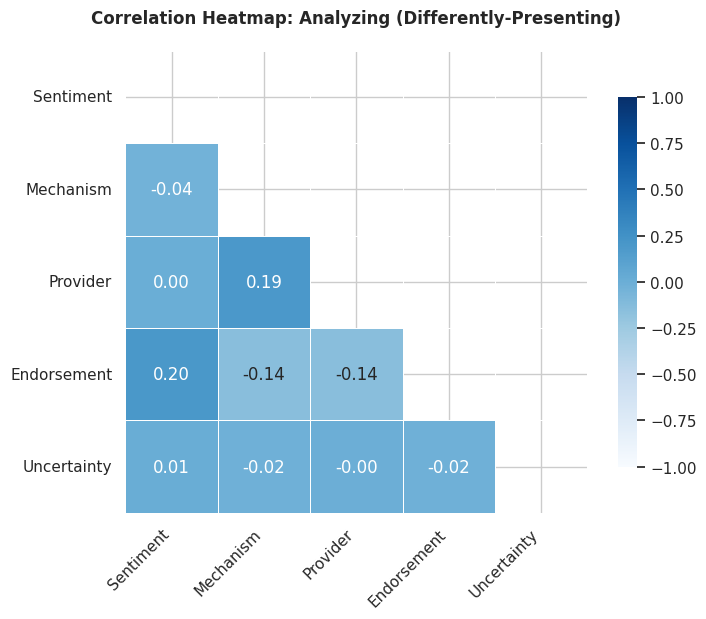

/tmp/ipykernel_19265/857794818.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clean_phrase_labels, y=means.values, palette=bar_palette)


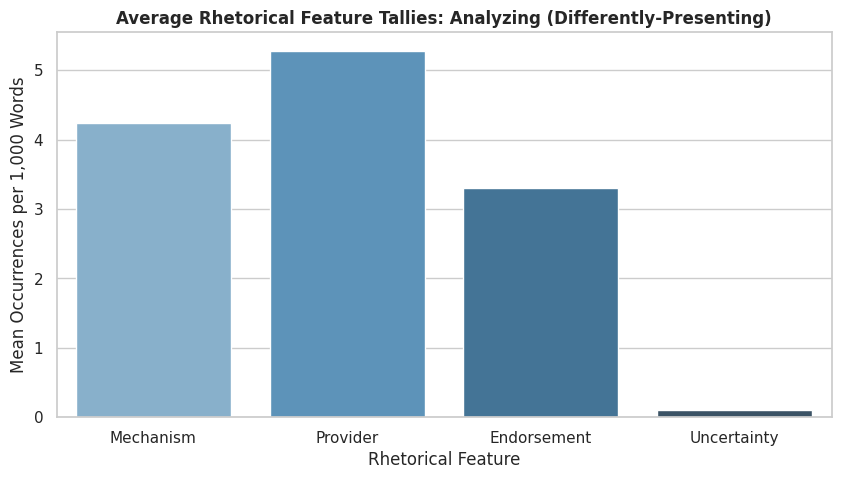

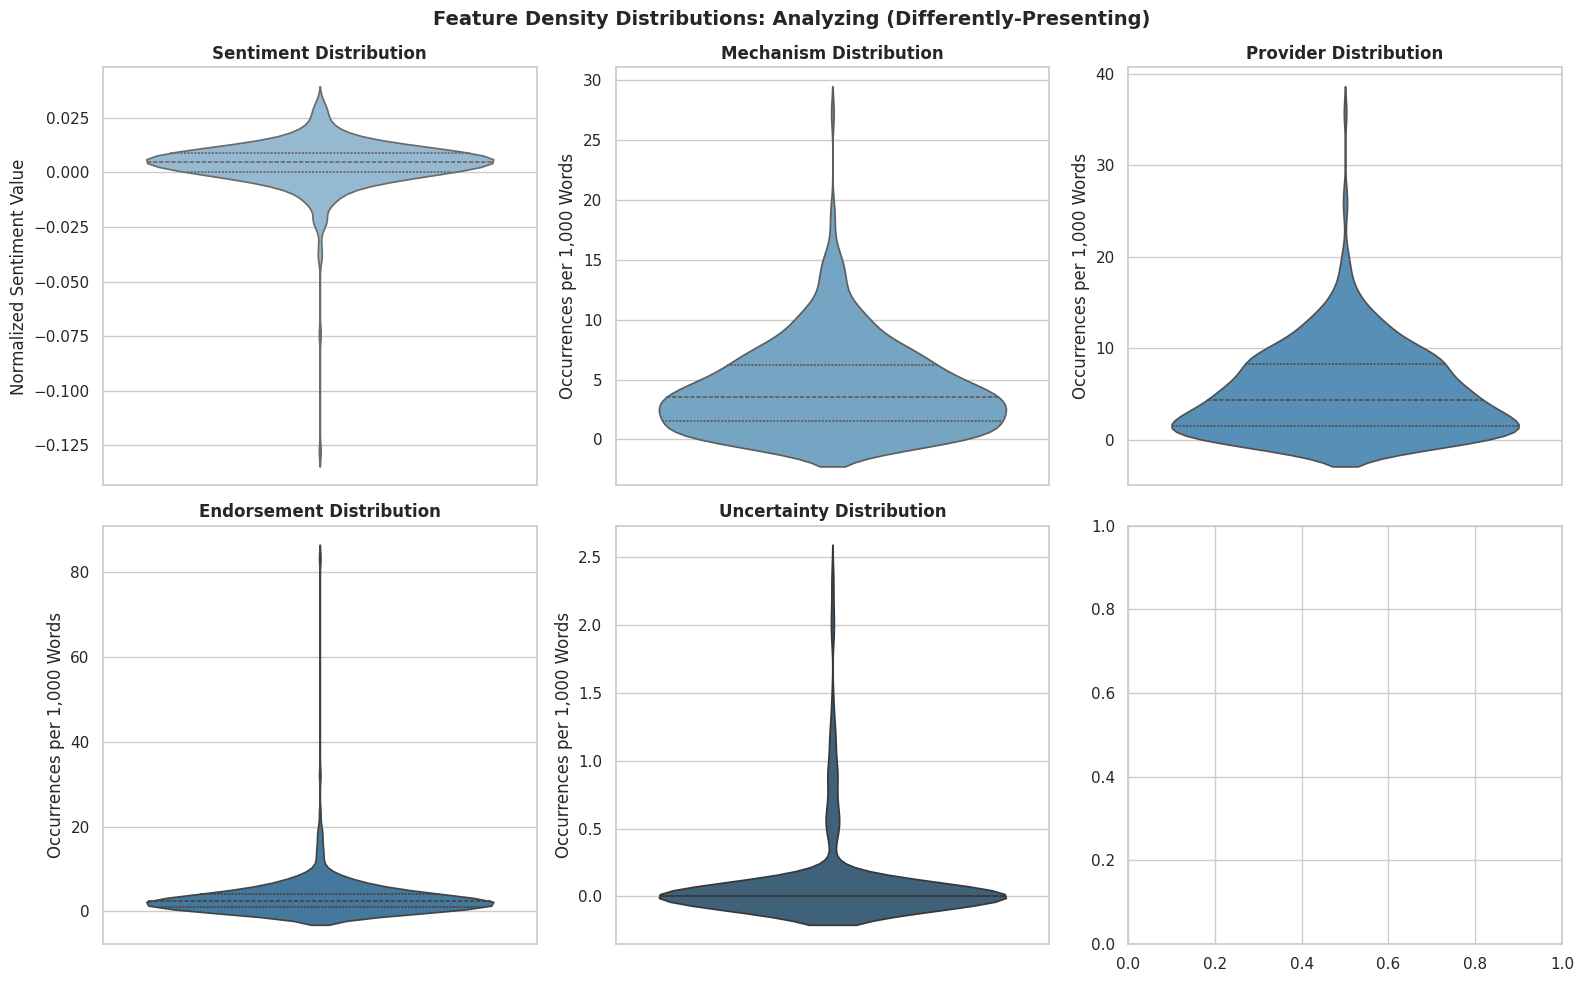


VISUALIZATIONS FOR: Identifying (Female-Specific)



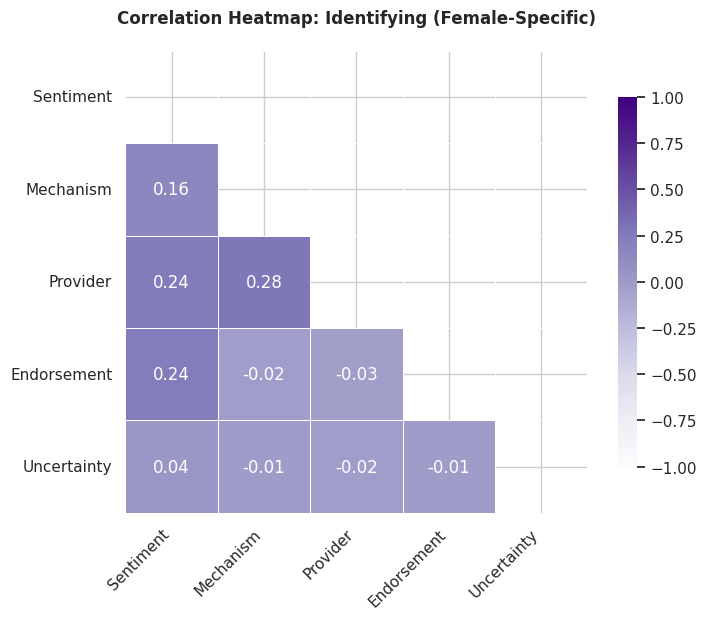

/tmp/ipykernel_19265/857794818.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clean_phrase_labels, y=means.values, palette=bar_palette)


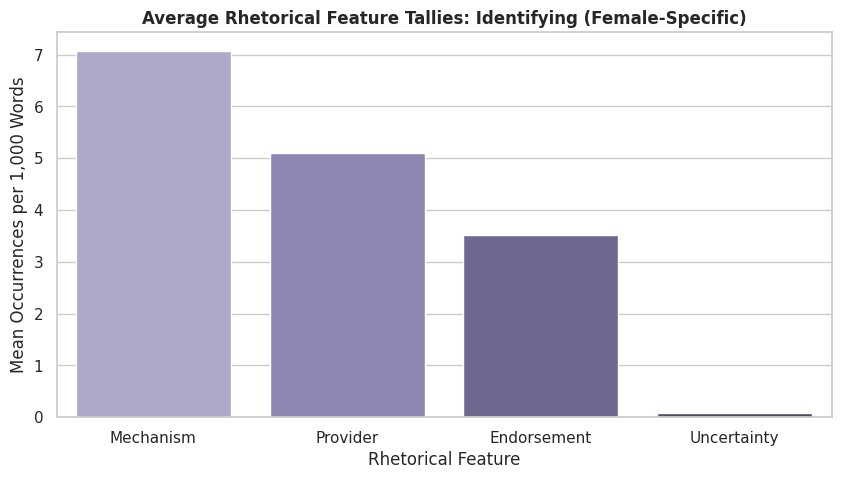

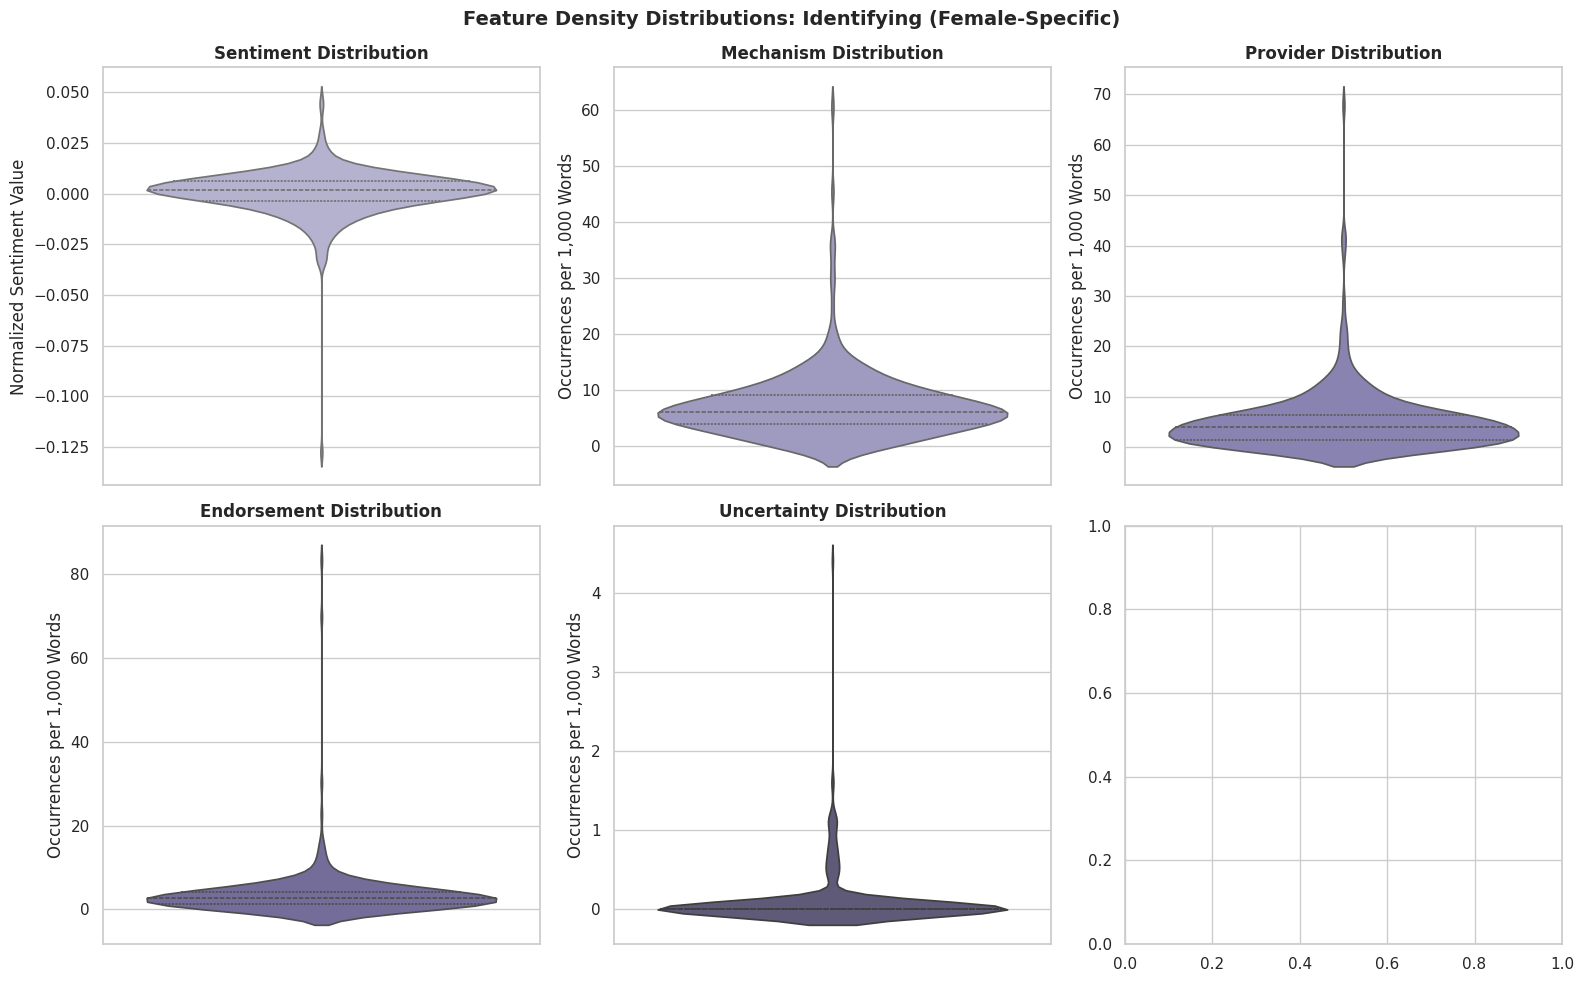

In [ ]:
# --- 2. Isolated Visualizations ---
corr_cols = [
    'sentiment_score', 'mechanism_phrases_score', 'provider_phrases_score',
    'endorsement_phrases_score', 'uncertainty_phrases_score'
]
phrase_cols = [col for col in corr_cols if col != 'sentiment_score']
clean_labels = [c.replace('_phrases_score', '').replace('_score', '').capitalize() for c in corr_cols]
clean_phrase_labels = [c.replace('_phrases_score', '').capitalize() for c in phrase_cols]

def plot_isolated_dataset(df, dataset_title, color_map, bar_palette):
    print(f"\n{'='*60}\nVISUALIZATIONS FOR: {dataset_title}\n{'='*60}\n")

    # Feature Correlation Heatmap
    plt.figure(figsize=(8, 6))
    corr_matrix = df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(
        corr_matrix, mask=mask, cmap=color_map, vmax=1, vmin=-1, center=0,
        square=True, linewidths=.5, annot=True, fmt=".2f", cbar_kws={"shrink": .8}
    )
    plt.title(f'Correlation Heatmap: {dataset_title}', fontweight='bold', pad=20)
    plt.xticks(ticks=np.arange(len(corr_cols))+0.5, labels=clean_labels, rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(corr_cols))+0.5, labels=clean_labels, rotation=0)
    plt.show()

    # Corpus Feature Profile
    plt.figure(figsize=(10, 5))
    means = df[phrase_cols].mean()

    sns.barplot(x=clean_phrase_labels, y=means.values, palette=bar_palette)
    plt.title(f'Average Rhetorical Feature Tallies: {dataset_title}', fontweight='bold')
    plt.ylabel('Mean Occurrences per 1,000 Words')
    plt.xlabel('Rhetorical Feature')
    plt.show()

    # Distribution Violin Plots
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
    axes = axes.flatten()

    for i, metric in enumerate(corr_cols):
        sns.violinplot(
            data=df, y=metric,
            color=sns.color_palette(bar_palette)[i % len(sns.color_palette(bar_palette))],
            inner='quartile', ax=axes[i]
        )
        axes[i].set_title(f'{clean_labels[i]} Distribution', fontweight='bold')

        if metric == 'sentiment_score':
            axes[i].set_ylabel('Normalized Sentiment Value')
        else:
            axes[i].set_ylabel('Occurrences per 1,000 Words')

        axes[i].set_xticks([])

    plt.suptitle(f'Feature Density Distributions: {dataset_title}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_isolated_dataset(
    analyzing_df,
    "Analyzing (Differently-Presenting)",
    color_map="Blues",
    bar_palette="Blues_d"
)

plot_isolated_dataset(
    identifying_df,
    "Identifying (Female-Specific)",
    color_map="Purples",
    bar_palette="Purples_d"
)


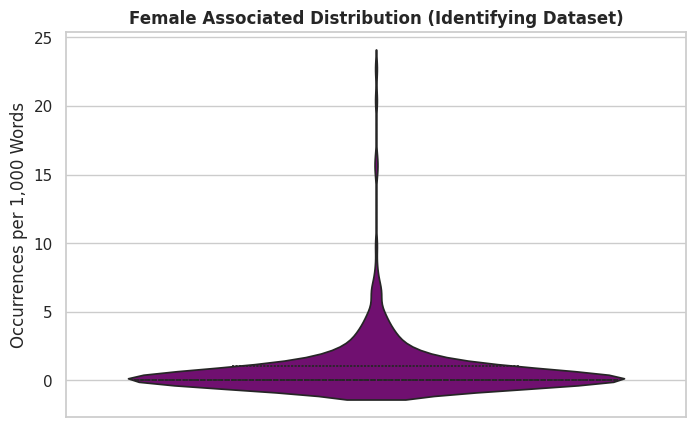

In [ ]:
# --- 3. Isolated Female Associated Profile ---
if 'female_associated_score' in identifying_df.columns:
    plt.figure(figsize=(8, 5))
    sns.violinplot(
        data=identifying_df,
        y='female_associated_score',
        color='purple',
        inner='quartile'
    )
    plt.title('Female Associated Distribution (Identifying Dataset)', fontweight='bold')
    plt.ylabel('Occurrences per 1,000 Words')
    plt.xticks([])
    plt.show()

### One-Way ANOVA Test



In [ ]:
import scipy.stats as stats
import pandas as pd

def perform_anova(df1, df2, metrics):
    results = []
    for metric in metrics:
        if metric in df1.columns and metric in df2.columns:
            f_stat, p_value = stats.f_oneway(df1[metric].dropna(), df2[metric].dropna())
            results.append({
                'Metric': metric,
                'F-Statistic': f_stat,
                'P-Value': p_value
            })
    return pd.DataFrame(results)

# Define the metrics calculated in the rule-based NLP pipeline
rule_based_metrics = [
    'sentiment_score',
    'mechanism_phrases_score',
    'provider_phrases_score',
    'endorsement_phrases_score',
    'uncertainty_phrases_score',
    'female_associated_score',
    'comprehensiveness_score'
]

# Execute ANOVA
anova_results_rule = perform_anova(analyzing_df, identifying_df, rule_based_metrics)
print("Rule-Based Text Analysis ANOVA Results:")
print(anova_results_rule)

Rule-Based Text Analysis ANOVA Results:
                      Metric  F-Statistic       P-Value
0            sentiment_score    14.763576  1.314220e-04
1    mechanism_phrases_score    64.467835  3.457377e-15
2     provider_phrases_score     0.213226  6.443752e-01
3  endorsement_phrases_score     0.282497  5.952156e-01
4  uncertainty_phrases_score     0.513422  4.738681e-01
5    female_associated_score   253.283866  8.236768e-50
6    comprehensiveness_score          NaN           NaN


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
target_metrics = [
    'word_count',
    'sentiment_score',
    'mechanism_phrases_score',
    'provider_phrases_score',
    'endorsement_phrases_score',
    'uncertainty_phrases_score',
    'female_associated_score',
    'semantic_mechanism_phrases_score',
    'semantic_provider_phrases_score',
    'semantic_endorsement_phrases_score',
    'semantic_uncertainty_phrases_score',
    'semantic_female_associated_score'
]

existing_metrics = [metric for metric in target_metrics if metric in identifying_df.columns]
identifying_means = identifying_df[existing_metrics].mean()
print(identifying_means)

word_count                   1259.260759
sentiment_score                 0.000552
mechanism_phrases_score         7.079458
provider_phrases_score          5.101017
endorsement_phrases_score       3.514144
uncertainty_phrases_score       0.089633
female_associated_score         0.926007
dtype: float64


In [ ]:
existing_metrics = [metric for metric in target_metrics if metric in analyzing_df.columns]
analyzing_means = analyzing_df[existing_metrics].mean()
print(analyzing_means)

word_count                   1204.134940
sentiment_score                 0.003710
mechanism_phrases_score         4.234287
provider_phrases_score          5.282261
endorsement_phrases_score       3.302447
uncertainty_phrases_score       0.106907
female_associated_score        10.028538
dtype: float64
